## Objective

- The objective of this notebook is to create forecasting baselines for the demand prediction task.
- In this step, only baseline models will be created. No machine learning model will be trained yet.
- These baselines will be used as reference points in the next stages, helping evaluate whether future ML models are actually improving the forecast performance.


In [1]:
import os 
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
ROOT = Path("..").resolve()
os.chdir(ROOT)

DATA_PATH = Path("data/processed/daily_product_sales.csv")

df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
print("columns:", list(df.columns))
print(f"Date range: {df['sale_date'].min()} to {df['sale_date'].max()}")
df.head()

shape: (6168, 9)
columns: ['product_name', 'sale_date', 'quantity_sold', 'total_revenue_brl', 'estimated_profit_brl', 'discount_pct', 'unit_price_brl', 'current_stock_snapshot', 'weather_condition']
Date range: 2025-01-01 to 2026-05-29


,product_name,sale_date,quantity_sold,total_revenue_brl,estimated_profit_brl,discount_pct,unit_price_brl,current_stock_snapshot,weather_condition
0,Bag Delivery 45L,2025-01-01,5.0,889.97,414.97,7.5,178.1725,84.0,Chuva Forte
1,Intercomunicador,2025-01-01,0.0,0.00,0.00,NaN,NaN,NaN,NaN
2,Carregador USB Moto,2025-01-01,0.0,0.00,0.00,NaN,NaN,NaN,NaN
3,Luva Motoboy,2025-01-01,10.0,777.04,527.04,5.0,78.2460,71.2,Ensolarado
4,Capacete Pro Tork,2025-01-01,7.0,2265.01,1005.01,5.0,326.7925,65.5,Nublado


## Build a Time Series With the Choosed Product
- I chose `Bag Delivery 45L` as an initial product to validate the forecasting methodology before applying it to all products.

In [2]:
product_data = df[df["product_name"] == "Bag Delivery 45L"]
product_data = product_data.sort_values("sale_date")
product_data["sale_date"] = pd.to_datetime(product_data["sale_date"], errors="coerce")
product_data["sale_date"].dtype

dtype('<M8[ns]')

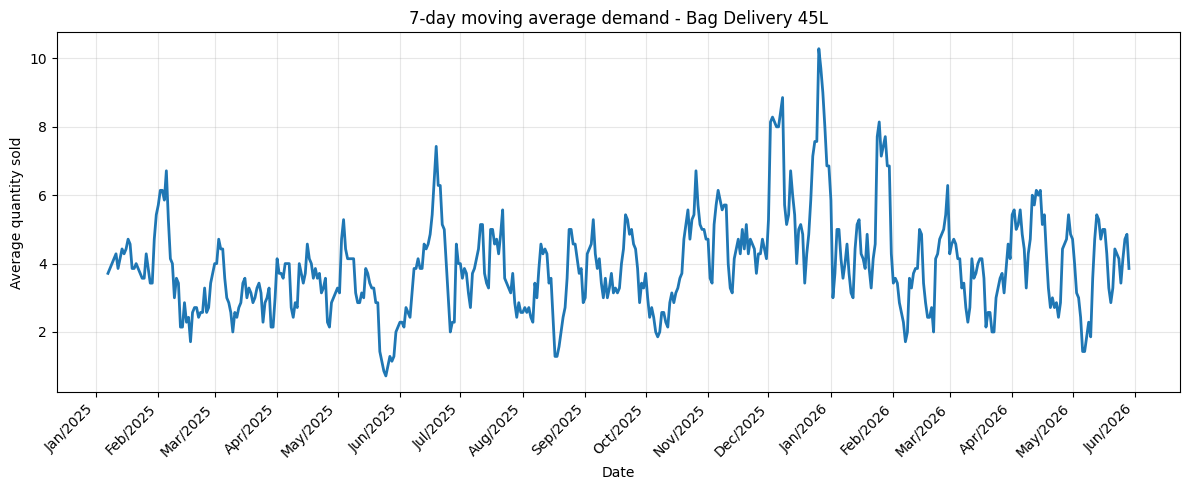

In [3]:
product_data["rolling_7d"] = (
    product_data["quantity_sold"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    product_data["sale_date"],
    product_data["rolling_7d"],
    linewidth=2
)

plt.title("7-day moving average demand - Bag Delivery 45L")
plt.xlabel("Date")
plt.ylabel("Average quantity sold")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))

plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## Create and View The Train/Test Split

In [4]:
train, test = train_test_split(
    product_data,
    test_size=0.2,
    shuffle=False
)

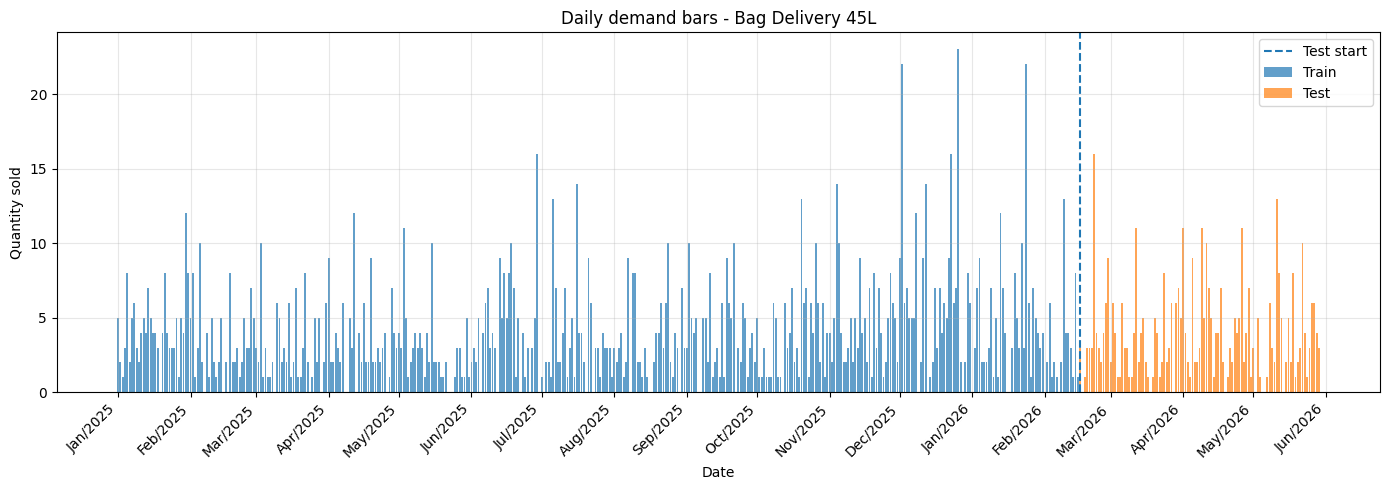

In [5]:
product_name = "Bag Delivery 45L"

train_product = train[train["product_name"] == product_name].copy()
test_product = test[test["product_name"] == product_name].copy()

train_product["sale_date"] = pd.to_datetime(train_product["sale_date"])
test_product["sale_date"] = pd.to_datetime(test_product["sale_date"])

train_product = train_product.sort_values("sale_date")
test_product = test_product.sort_values("sale_date")

product_data = pd.concat([train_product, test_product]).sort_values("sale_date")
product_data["rolling_7d"] = product_data["quantity_sold"].rolling(window=7).mean()

split_date = test_product["sale_date"].min()

plt.figure(figsize=(14, 5))

plt.bar(
    train_product["sale_date"],
    train_product["quantity_sold"],
    label="Train",
    alpha=0.7
)

plt.bar(
    test_product["sale_date"],
    test_product["quantity_sold"],
    label="Test",
    alpha=0.7
)

plt.axvline(
    split_date,
    linestyle="--",
    label="Test start"
)

plt.title(f"Daily demand bars - {product_name}")
plt.xlabel("Date")
plt.ylabel("Quantity sold")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))

plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

## Baseline 1 - Last Value Forecast

In [6]:
baseline_df = pd.concat([train, test]).copy()

baseline_df["sale_date"] = pd.to_datetime(baseline_df["sale_date"])

baseline_df = baseline_df.sort_values(["product_name", "sale_date"])

baseline_df["last_value_forecast"] = (
    baseline_df
    .groupby("product_name")["quantity_sold"]
    .shift(1)
)

test_baseline = baseline_df.loc[test.index].copy()
test_baseline = test_baseline.dropna(subset=["last_value_forecast"])

test_baseline.head(5)

,product_name,sale_date,quantity_sold,total_revenue_brl,estimated_profit_brl,discount_pct,unit_price_brl,current_stock_snapshot,weather_condition,rolling_7d,last_value_forecast
4939,Bag Delivery 45L,2026-02-16,3.0,542.81,257.81,2.500000,179.330000,70.000000,Chuva Leve,3.428571,1.0
4955,Bag Delivery 45L,2026-02-17,0.0,0.00,0.00,NaN,NaN,NaN,NaN,2.857143,3.0
4964,Bag Delivery 45L,2026-02-18,1.0,178.53,83.53,15.000000,178.530000,44.000000,Ensolarado,2.428571,0.0
4970,Bag Delivery 45L,2026-02-19,3.0,528.86,243.86,3.333333,176.286667,60.333333,Chuva Forte,2.428571,1.0
4991,Bag Delivery 45L,2026-02-20,3.0,543.08,258.08,2.500000,181.405000,58.500000,Ensolarado,2.714286,3.0


## Baseline 1 Evaluation

In [7]:
y_true = test_baseline["quantity_sold"]
y_pred = test_baseline["last_value_forecast"]

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

non_zero_mask = y_true != 0

mape = (
    np.mean(
        np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
    ) * 100
)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 3.30
RMSE: 4.28
MAPE: 111.06%


## Baseline 2 - Moving Average Forecast

In [8]:
baseline_df["sale_date"] = pd.to_datetime(baseline_df["sale_date"])

baseline_df = baseline_df.sort_values(["product_name", "sale_date"])

baseline_df["rolling_7d_forecast"] = (
    baseline_df
    .groupby("product_name")["quantity_sold"]
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

test_baseline = baseline_df.loc[test.index].copy()

test_baseline.head(5)

,product_name,sale_date,quantity_sold,total_revenue_brl,estimated_profit_brl,discount_pct,unit_price_brl,current_stock_snapshot,weather_condition,rolling_7d,last_value_forecast,rolling_7d_forecast
4939,Bag Delivery 45L,2026-02-16,3.0,542.81,257.81,2.500000,179.330000,70.000000,Chuva Leve,3.428571,1.0,4.857143
4955,Bag Delivery 45L,2026-02-17,0.0,0.00,0.00,NaN,NaN,NaN,NaN,2.857143,3.0,3.428571
4964,Bag Delivery 45L,2026-02-18,1.0,178.53,83.53,15.000000,178.530000,44.000000,Ensolarado,2.428571,0.0,2.857143
4970,Bag Delivery 45L,2026-02-19,3.0,528.86,243.86,3.333333,176.286667,60.333333,Chuva Forte,2.428571,1.0,2.428571
4991,Bag Delivery 45L,2026-02-20,3.0,543.08,258.08,2.500000,181.405000,58.500000,Ensolarado,2.714286,3.0,2.428571


## Baseline 2 Evaluation

In [ ]:
y_true = test_baseline["quantity_sold"]
y_pred = test_baseline["rolling_7d_forecast"]

mae_7d = mean_absolute_error(y_true, y_pred)

rmse_7d = np.sqrt(mean_squared_error(y_true, y_pred))

non_zero_mask = y_true != 0

mape_7d = (
    np.mean(
        np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
    ) * 100
)

print(f"MAE: {mae_7d:.2f}")
print(f"RMSE: {rmse_7d:.2f}")
print(f"MAPE: {mape_7d:.2f}%")

MAE: 2.62
RMSE: 3.48
MAPE: 91.76%


## Comparing Baselines

In [12]:
comparison_df = pd.DataFrame([
    {
    "Model": "Last Value",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape
    },
    {
    "Model": "Moving Average",
    "MAE": mae_7d,
    "RMSE": rmse_7d,
    "MAPE": mape_7d
    }
]).round(2)

comparison_df

,Model,MAE,RMSE,MAPE
0,Last Value,3.30,4.28,111.06
1,Moving Average,2.62,3.48,91.76


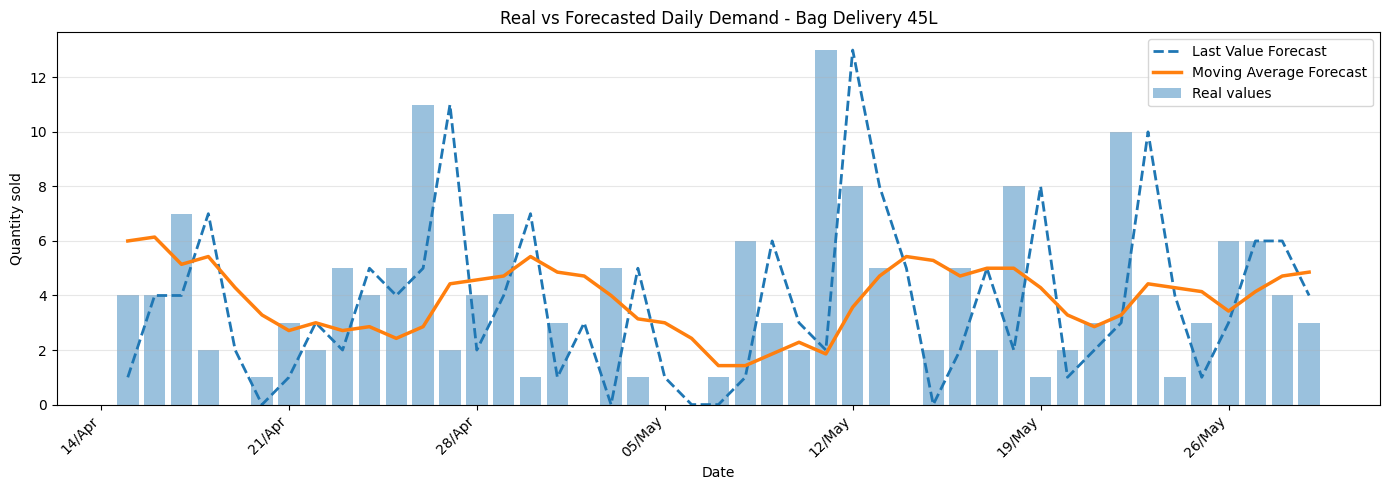

In [14]:
product_name = "Bag Delivery 45L"

plot_df = (
    test_baseline[test_baseline["product_name"] == product_name]
    .copy()
)

plot_df["sale_date"] = pd.to_datetime(plot_df["sale_date"])
plot_df = plot_df.sort_values("sale_date")

plot_df = plot_df.dropna(
    subset=[
        "quantity_sold",
        "last_value_forecast",
        "rolling_7d_forecast"
    ]
)

# Optional: show only the last 45 daily records to make the chart cleaner
plot_df = plot_df.tail(45)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    plot_df["sale_date"],
    plot_df["quantity_sold"],
    label="Real values",
    alpha=0.45
)

ax.plot(
    plot_df["sale_date"],
    plot_df["last_value_forecast"],
    linestyle="--",
    linewidth=2,
    label="Last Value Forecast"
)

ax.plot(
    plot_df["sale_date"],
    plot_df["rolling_7d_forecast"],
    linestyle="-",
    linewidth=2.5,
    label="Moving Average Forecast"
)

ax.set_title(f"Real vs Forecasted Daily Demand - {product_name}")
ax.set_xlabel("Date")
ax.set_ylabel("Quantity sold")

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))

ax.set_ylim(bottom=0)

ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Baseline Findings

### Main Findings
- In general the **7 day moving average** performed better across all evaluation metrics:
  - MAE reduced by ≈ `20.6%`,
  - RMSE reduced by ≈ `18.7%`,
  - MAPE reduced by ≈ `17.4%`.
- The **MAE** is useful because it shows the average forecasting error in units sold.
- The **RMSE** is also important because it penalizes larger errors more strongly. In inventory forecasting, larger errors can lead to
  - stockouts, when the demand is underestimated;
  - excess stock, when the demand is overestimated.
- The **MAPE should be interpreted carefully** because this dataset contains low-demand products and possibly zero-sales days, which can make percentage errors look very high.

### Limitations
- These baselines are simple and do **not use external information** such as `promotions, weather, sales channel, product category or seasonality`
- The Last Value baselines is too sensitive to **daily fluctuations** and can react late to sudden changes in demand.
- The Moving Average baseline is more stable, but it may smooth sudden spikes and fail to capture fast demand changes.

### Next Step
The next step will be responsible for the **Feature Engineering**. In this phase, new predictive variables will be created from the dataset to help future ML models learn demand patterns more effectively.

## Observation
This baseline evaluates short-term daily forecasting and will later be expanded to support the **14-day** stock recommendation horizon.